# Bayesian Optimization

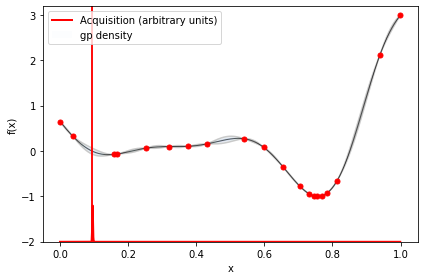

In [1]:
from GPyOpt.methods import BayesianOptimization
import numpy as np


def f(x): return (6*x-2)**2 * np.sin(12*x-4)
domain = [{'name': 'var_1', 'type': 'continuous', 'domain': (0, 1)}]

myBopt = BayesianOptimization(f=f, domain=domain)
myBopt.run_optimization(max_iter=15)
myBopt.plot_acquisition()

Text(0, 0.5, 'f(x)')

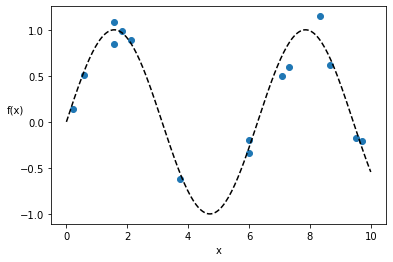

In [2]:
import pymc3 as pm
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.uniform(0, 10, size=15)
y = np.random.normal(np.sin(x), 0.1)
plt.plot(x, y, 'o')
true_x = np.linspace(0, 10, 200)
plt.plot(true_x, np.sin(true_x), 'k--')
plt.xlabel('x')
plt.ylabel('f(x)', rotation=0)

In [27]:
X = x[:, None]

with pm.Model() as model_reg:
    ls = pm.Gamma('length', 2, 0.5)
    cov = pm.gp.cov.ExpQuad(1, ls=ls)
    gp = pm.gp.Marginal(cov_func=cov)
    eps = pm.HalfNormal('eps', 25)
    y_pred = gp.marginal_likelihood('y_pref', X=X, y=y, noise=eps)
    trace_reg = pm.sample(2000, chains=1)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [eps, length]


Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 3 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Got error No model on context stack. trying to find log_likelihood in translation.
Got error No model on context stack. trying to find log_likelihood in translation.


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x156d742e0>,
      dtype=object)

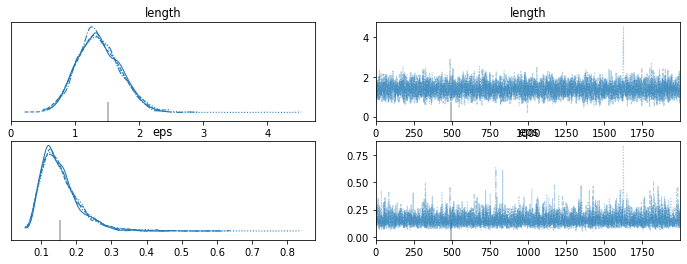

In [8]:
az.plot_trace(trace_reg)

In [9]:
X_new = np.linspace(np.floor(x.min()), np.ceil(x.max()), 100)[:,None]

with model_reg:
    f_pred = gp.conditional('f_pred', X_new)

In [11]:
with model_reg:
    pred_samples = pm.sample_posterior_predictive(trace_reg, var_names=["f_pred"], samples=82)

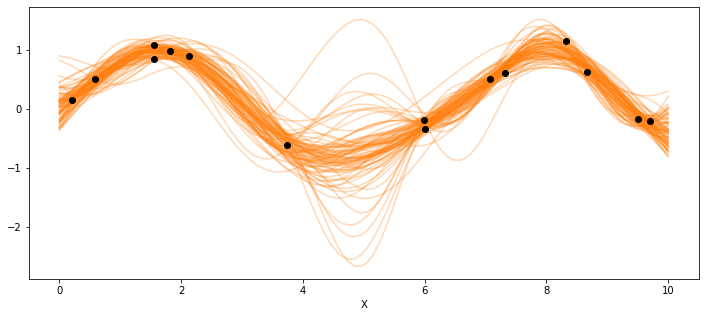

In [12]:
_, ax = plt.subplots(figsize=(12,5))
ax.plot(X_new, pred_samples['f_pred'].T, 'C1-', alpha=0.3)
ax.plot(X, y, 'ko')
ax.set_xlabel('X')
plt.savefig('B11197_07_06.png')

In [14]:
with model_reg:
    pred_func = pm.sample_posterior_predictive(trace_reg, var_names=["f_pred"], samples=1)


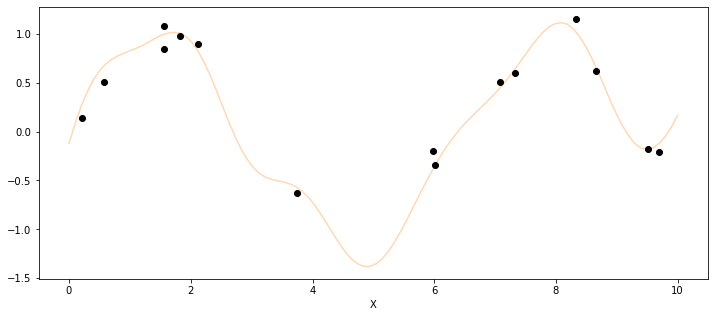

In [22]:
_, ax = plt.subplots(figsize=(12,5))
ax.plot(X_new, pred_func['f_pred'].T, 'C1-', alpha=0.3)
ax.plot(X, y, 'ko')
ax.set_xlabel('X')
plt.savefig('B11197_07_06.png')

In [24]:
idx = np.argmax(pred_func['f_pred'])

80

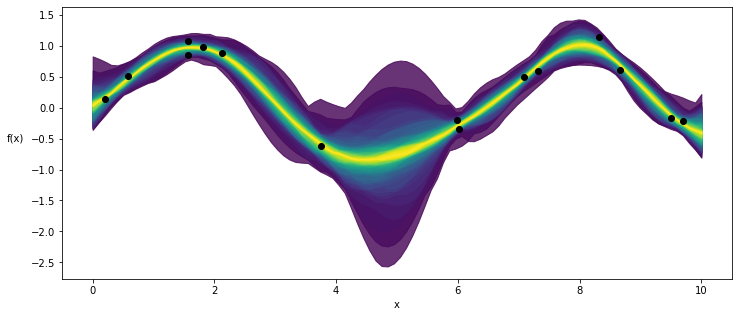

In [25]:
_, ax = plt.subplots(figsize=(12,5))

pm.gp.util.plot_gp_dist(ax, pred_samples['f_pred'], X_new, palette='viridis', plot_samples=False);

ax.plot(X, y, 'ko')
ax.set_xlabel('x')
ax.set_ylabel('f(x)', rotation=0, labelpad=15)
plt.savefig('B11197_07_07.png')